# Posterior for S. aureus local recombination rate and mutation rate using SBI

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
import seaborn as sns
from Bio import Phylo
import torch
import torch.nn as nn
from torch.distributions import Uniform
import sbi
from sbi.utils.user_input_checks import MultipleIndependent
from sbi.neural_nets import posterior_nn
from sbi.neural_nets.embedding_nets import FCEmbedding
from sbi.inference import NPE_C
from sbi.analysis import plot_summary
import sys
sys.path.append('../pysimARG')
from discrete_uniform import DiscreteUniform

torch_device = "cpu"

## Load simulation data

Load staph gene data and clonal tree.

In [2]:
# Load phylo tree and convert to ClonalTree format
phylo_tree = Phylo.read("../data/staph/saureus_clonal.nwk", "newick")
Phylo.draw_ascii(phylo_tree)

                                                                   , C1139
                                                                  ,|
                                                                  |, C9658
                                                                  ||
                                                                  |, C1282
                                                                  ||
                      ____________________________________________|, C1280
                     |                                            ||
                     |                                            || C1080
                     |                                            |
                     |                                            |_ C1079
                     |                                            |
                     |                                            , C1147
                     |                                          

In [3]:
x_obs_df = pd.read_csv("../data/staph/core_gene_summary_stats.csv", index_col=0)
x_obs_np = x_obs_df.to_numpy()
x_obs_torch = torch.tensor(x_obs_np, device=torch_device)
x_obs_torch = x_obs_torch.to(torch.float32)
x_obs_torch.shape, x_obs_torch.dtype

(torch.Size([1983, 46]), torch.float32)

### Delete observations with no signal

In [4]:
no_signal_id = np.where(x_obs_np[:, 33] == 0)[0]
no_signal_id.shape, no_signal_id[:10]

((18,), array([ 137,  140,  236,  657,  659,  767,  773, 1036, 1485, 1497]))

In [5]:
x_obs_np = np.delete(x_obs_np, no_signal_id, axis=0)
x_obs_torch = torch.tensor(x_obs_np, device=torch_device)
x_obs_torch = x_obs_torch.to(torch.float32)
x_obs_np.shape, x_obs_torch.shape, x_obs_torch.dtype

((1965, 46), torch.Size([1965, 46]), torch.float32)

## Load simulation data

In [6]:
theta1 = np.loadtxt('../data/staph/ClonalOrigin_sim/change_theta/theta1.csv', delimiter=",")
x1 = np.loadtxt('../data/staph/ClonalOrigin_sim/change_theta/x1.csv', delimiter=",")

theta2 = np.loadtxt('../data/staph/ClonalOrigin_sim/change_theta/theta2.csv', delimiter=",")
x2 = np.loadtxt('../data/staph/ClonalOrigin_sim/change_theta/x2.csv', delimiter=",")

theta3 = np.loadtxt('../data/staph/ClonalOrigin_sim/change_theta/theta3.csv', delimiter=",")
x3 = np.loadtxt('../data/staph/ClonalOrigin_sim/change_theta/x3.csv', delimiter=",")

theta4 = np.loadtxt('../data/staph/ClonalOrigin_sim/change_theta/theta4.csv', delimiter=",")
x4 = np.loadtxt('../data/staph/ClonalOrigin_sim/change_theta/x4.csv', delimiter=",")

theta5 = np.loadtxt('../data/staph/ClonalOrigin_sim/change_theta/theta5.csv', delimiter=",")
x5 = np.loadtxt('../data/staph/ClonalOrigin_sim/change_theta/x5.csv', delimiter=",")

x = np.vstack([x1, x2, x3, x4, x5])
theta = np.vstack([theta1, theta2, theta3, theta4, theta5])

print(theta.shape, x.shape)

(50000, 3) (50000, 46)


In [7]:
theta = torch.tensor(theta, device=torch_device)
theta = theta.to(torch.float32)
theta_numpy = theta.cpu().numpy()

x = torch.tensor(x, device=torch_device)
x = x.to(torch.float32)
x_numpy = x.cpu().numpy()

### Find out-of-range observations

In [8]:
ignore_indices = []
no_segregation = []
out_stats = dict()
for i in range(x_obs_torch.shape[0]):
    ignore_i = False
    out_index = []
    for j in range(46):
        max_j = torch.max(x[:, j])
        min_j = torch.min(x[:, j])
        obs_j = x_obs_torch[i, j]
        if obs_j < min_j or obs_j > max_j:
            ignore_i = True
            out_index.append(j)
        if j == 33 and obs_j == 0:
            no_segregation.append(i)
    if ignore_i or torch.isnan(x_obs_torch[i, :]).any():
        print(f"Observation {i} is outside the range of simulated data.")
        ignore_indices.append(i)
        out_stats[i] = out_index

Observation 207 is outside the range of simulated data.
Observation 459 is outside the range of simulated data.
Observation 1233 is outside the range of simulated data.
Observation 1306 is outside the range of simulated data.
Observation 1322 is outside the range of simulated data.
Observation 1416 is outside the range of simulated data.
Observation 1807 is outside the range of simulated data.


In [9]:
len(ignore_indices), len(no_segregation), len(out_stats)

(7, 0, 7)

In [10]:
out_index_all = []
for i in range(len(ignore_indices)):
    idx = ignore_indices[i]
    out_index_all += out_stats[idx]

In [11]:
from collections import Counter

integer_counts = Counter(out_index_all)

In [12]:
for i in range(32):
    print(f"Index {i}: {integer_counts[i]}")

Index 0: 0
Index 1: 0
Index 2: 0
Index 3: 0
Index 4: 0
Index 5: 0
Index 6: 0
Index 7: 0
Index 8: 0
Index 9: 0
Index 10: 0
Index 11: 0
Index 12: 0
Index 13: 0
Index 14: 0
Index 15: 0
Index 16: 0
Index 17: 0
Index 18: 0
Index 19: 0
Index 20: 0
Index 21: 0
Index 22: 0
Index 23: 0
Index 24: 1
Index 25: 1
Index 26: 0
Index 27: 0
Index 28: 2
Index 29: 0
Index 30: 0
Index 31: 0


In [13]:
for i in range(32, 46):
    print(f"Index {i}: {integer_counts[i]}")

Index 32: 0
Index 33: 0
Index 34: 0
Index 35: 0
Index 36: 0
Index 37: 0
Index 38: 0
Index 39: 0
Index 40: 0
Index 41: 0
Index 42: 0
Index 43: 3
Index 44: 0
Index 45: 0


Drop columns for exact LD and G4 values

In [14]:
# drop_columns = list(range(0, 8)) + list(range(16, 32))
# len(drop_columns), drop_columns

In [15]:
# x_obs_np = np.delete(x_obs_np, drop_columns, axis=1)
# x_obs_torch = torch.tensor(x_obs_np, device=torch_device)
# x_obs_torch = x_obs_torch.to(torch.float32)
# x_obs_np.shape, x_obs_torch.shape, x_obs_torch.dtype

In [16]:
# x = x[:, [i for i in range(x.shape[1]) if i not in drop_columns]]
# x_numpy = x.cpu().numpy()
# x.shape, x_numpy.shape

## NPE

### Create prior to pass range knowledge to NPE

In [17]:
prior_rho = Uniform(low=torch.tensor([0.0]), high=torch.tensor([0.1]))
prior_theta = Uniform(low=torch.tensor([0.0]), high=torch.tensor([0.02]))
prior_L = DiscreteUniform(low=torch.tensor([20.0]), high=torch.tensor([10000.0]))

prior = MultipleIndependent(
    dists=[prior_rho, prior_theta, prior_L],
    validate_args=False,
    device=torch_device
)

### Embedding summary network where keep the gene length dimension

In [18]:
class LeaveLengthOut_NN(nn.Module):
    def __init__(self, input_dim=46, num_hiddens=50):
        super().__init__()
        
        # This MLP generates the first 3 features. 
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, num_hiddens),
            nn.ReLU(),
            nn.Linear(num_hiddens, num_hiddens),
            nn.ReLU(),
            nn.Linear(num_hiddens, 4)  # Output exactly 4 neurons
        )

    def forward(self, x):
        # 1. Get the 4 neurons from the MLP
        mlp_out = self.mlp(x)
        # 2. Extract the last element of the input vector
        last_element = x[:, -1:] 
        # 3. Concatenate them along the feature dimension
        out = torch.cat([mlp_out, last_element], dim=-1)
        
        return out

In [19]:
embedding_net = LeaveLengthOut_NN(input_dim=46, num_hiddens=50)

neural_posterior = posterior_nn(
    model="nsf", 
    embedding_net=embedding_net 
)

In [20]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference_summaryNN = NPE_C(prior=prior, density_estimator=neural_posterior, device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [21]:
density_estimator_summaryNN = inference_summaryNN.append_simulations(theta, x).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior_summaryNN = inference_summaryNN.build_posterior(density_estimator_summaryNN)

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\sbi\inference\trainers\npe\npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [0, 1, 2, 3, 4, 5, 8, 9, 12, 13, 17, 18, 19, 20, 21, 24, 25, 26, 27, 28, 29, 32, 36, 38, 39, 41, 42, 43, 44] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 102 epochs.

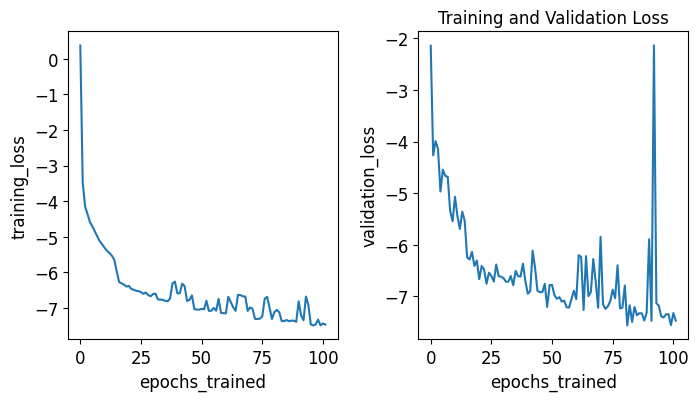

In [22]:
fig, axes = plot_summary(
    inference_summaryNN, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

### Save the trained NPE

In [82]:
save_path = "../data/staph/trained_npe_density_estimator_NN.pt"

torch.save(
    {
        "density_estimator": density_estimator_summaryNN,
        "prior": prior,
        "sbi_version": sbi.__version__,
        "learning_rate": learning_rate,
        "max_num_epochs": 500,
    },
    save_path,
)

### Plug in observation data to get posterior

In [23]:
theta_post = np.full((x_obs_torch.shape[0], num_posterior_samples, 3), np.nan)
theta_post.shape

(1965, 1000, 3)

In [56]:
for i in range(x_obs_torch.shape[0]):
    # if i in ignore_indices:
    #     continue

    theta_post_torch = posterior_summaryNN.sample((num_posterior_samples,),
                                                  x=x_obs_torch[i, :],
                                                  show_progress_bars=False,
                                                  reject_outside_prior=True)
    theta_post[i, :, :] = theta_post_torch.cpu().detach().numpy()

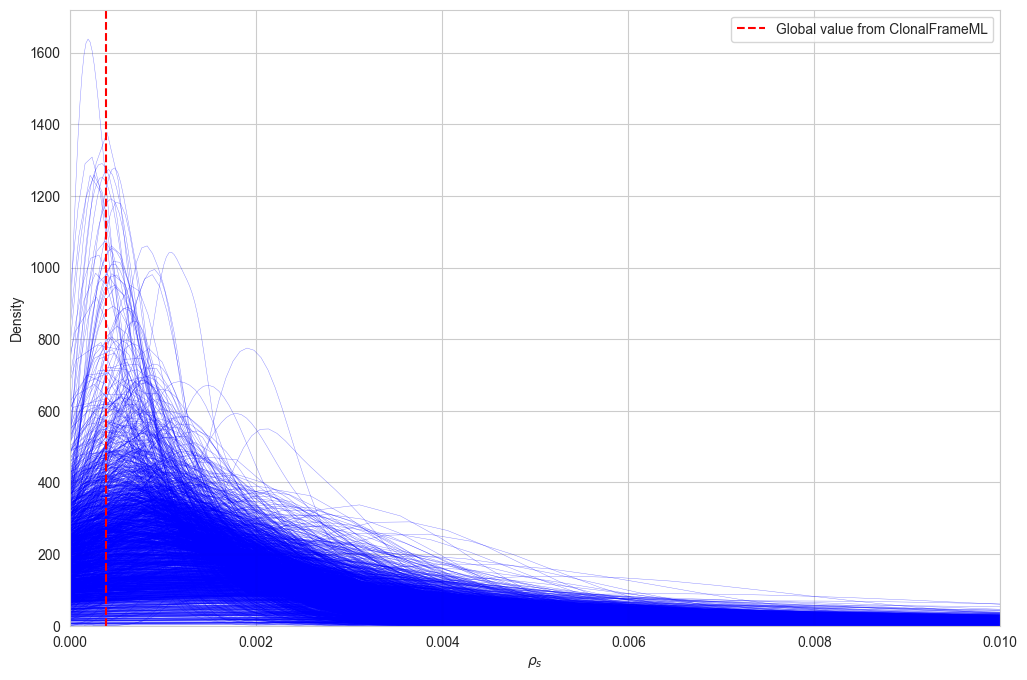

In [57]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
for i in range(0, x_obs_torch.shape[0]):
    if i in ignore_indices:
        continue
    sns.kdeplot(theta_post[i, :, 0], color='blue', linewidth=0.3, alpha=0.5)
plt.axvline(x=0.0003887292720131564, color='red', linestyle='dashed', label='Global value from ClonalFrameML')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.01)
plt.legend()
plt.show()

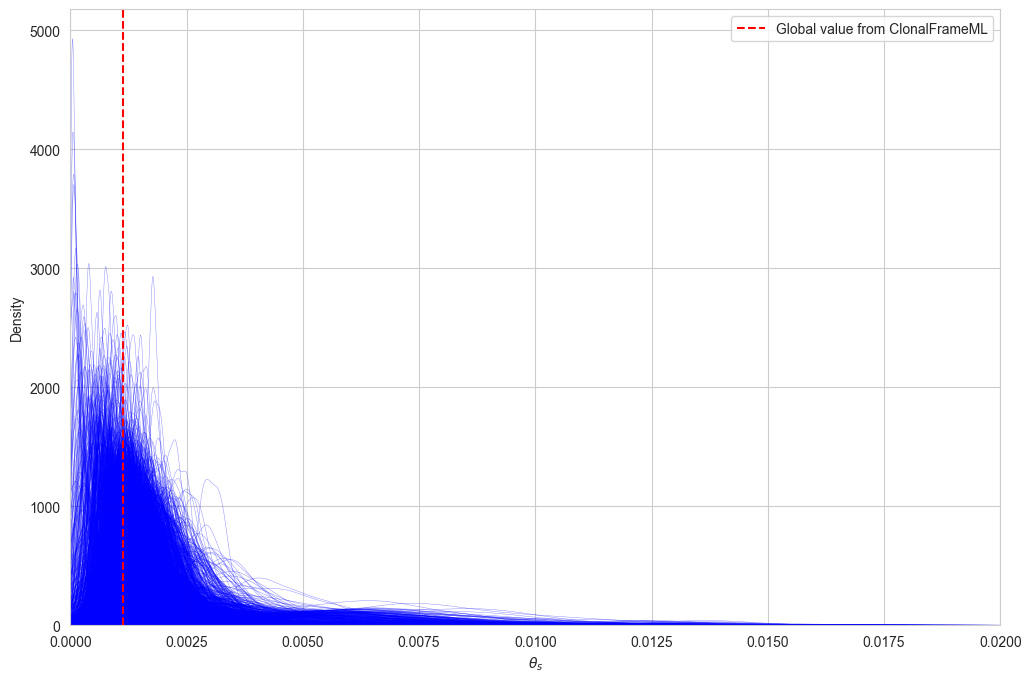

In [58]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
for i in range(0, x_obs_torch.shape[0]):
    if i in ignore_indices:
        continue
    sns.kdeplot(theta_post[i, :, 1], color='blue', linewidth=0.3, alpha=0.5)
plt.axvline(x=0.001133205859498758, color='red', linestyle='dashed', label='Global value from ClonalFrameML')
plt.xlabel(r'$\theta_s$')
plt.xlim(0.0, 0.02)
plt.legend()
plt.show()

### Plot bar plots by position

In [59]:
gene_info = pd.read_csv("../data/staph/core_gene_info.csv", index_col=0)
gene_info_np = gene_info.to_numpy()
gene_info.head()

,Gene_Length,Start_pos,End_pos,Alignment
Gene_ID,,,,
dnaA,1362,517,1878,True
dnaN,1134,2156,3289,True
SAR0003,246,3670,3915,True
recF,1113,3912,5024,True
gyrB,1932,5037,6968,True


In [60]:
plot_xlim = [0.0, 2902619.0]
samples_x = np.delete(gene_info_np[:, 1], no_signal_id)
samples_x.shape

(1965,)

In [61]:
posterior_median = np.median(theta_post[:, :, 0], axis=1)
posterior_median.shape

(1965,)

In [62]:
ci_lower_bounds = np.percentile(theta_post[:, :, 0], 2.5, axis=1)
ci_upper_bounds = np.percentile(theta_post[:, :, 0], 97.5, axis=1)
ci_lower_bounds.shape, ci_upper_bounds.shape

((1965,), (1965,))

In [63]:
lower_errors = posterior_median - ci_lower_bounds
upper_errors = ci_upper_bounds - posterior_median
yerr = [lower_errors, upper_errors]

In [64]:
median_rho = np.median(posterior_median)
median_rho

np.float64(0.0010316199623048306)

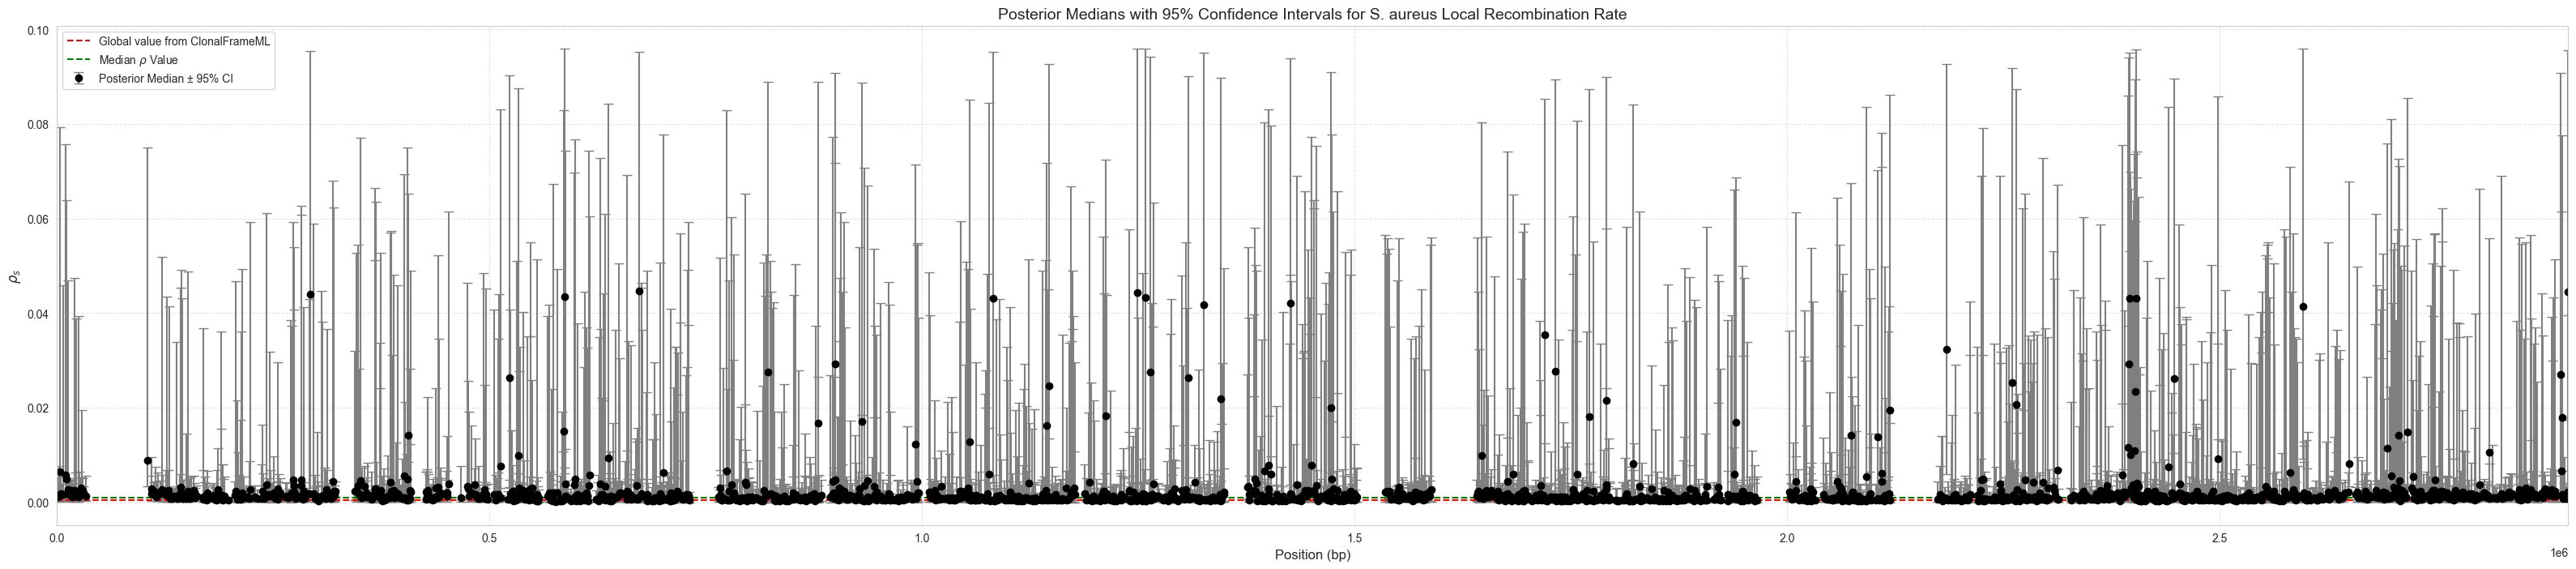

In [65]:
plt.figure(figsize=(40, 8))
plt.errorbar(samples_x, posterior_median, yerr=yerr, fmt='o', color='black', 
             ecolor='gray', capsize=4, elinewidth=1.5, markersize=6, 
             label='Posterior Median ± 95% CI')

plt.title("Posterior Medians with 95% Confidence Intervals for S. aureus Local Recombination Rate", fontsize=14)
plt.xlabel("Position (bp)", fontsize=12)
plt.ylabel(r'$\rho_s$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(y=0.0003887292720131564, color='red', linestyle='dashed', label='Global value from ClonalFrameML')
plt.axhline(y=median_rho, color='green', linestyle='dashed', label=r'Median $\rho$ Value')
plt.xlim(plot_xlim)
plt.legend()
plt.show()

In [66]:
posterior_median_theta = np.median(theta_post[:, :, 1], axis=1)
posterior_median_theta.shape

(1965,)

In [67]:
ci_lower_bounds_theta = np.percentile(theta_post[:, :, 1], 2.5, axis=1)
ci_upper_bounds_theta = np.percentile(theta_post[:, :, 1], 97.5, axis=1)
ci_lower_bounds_theta.shape, ci_upper_bounds_theta.shape

((1965,), (1965,))

In [68]:
lower_errors_theta = posterior_median_theta - ci_lower_bounds_theta
upper_errors_theta = ci_upper_bounds_theta - posterior_median_theta
yerr_theta = [lower_errors_theta, upper_errors_theta]

In [69]:
median_theta = np.median(posterior_median_theta)
median_theta

np.float64(0.0014704986242577434)

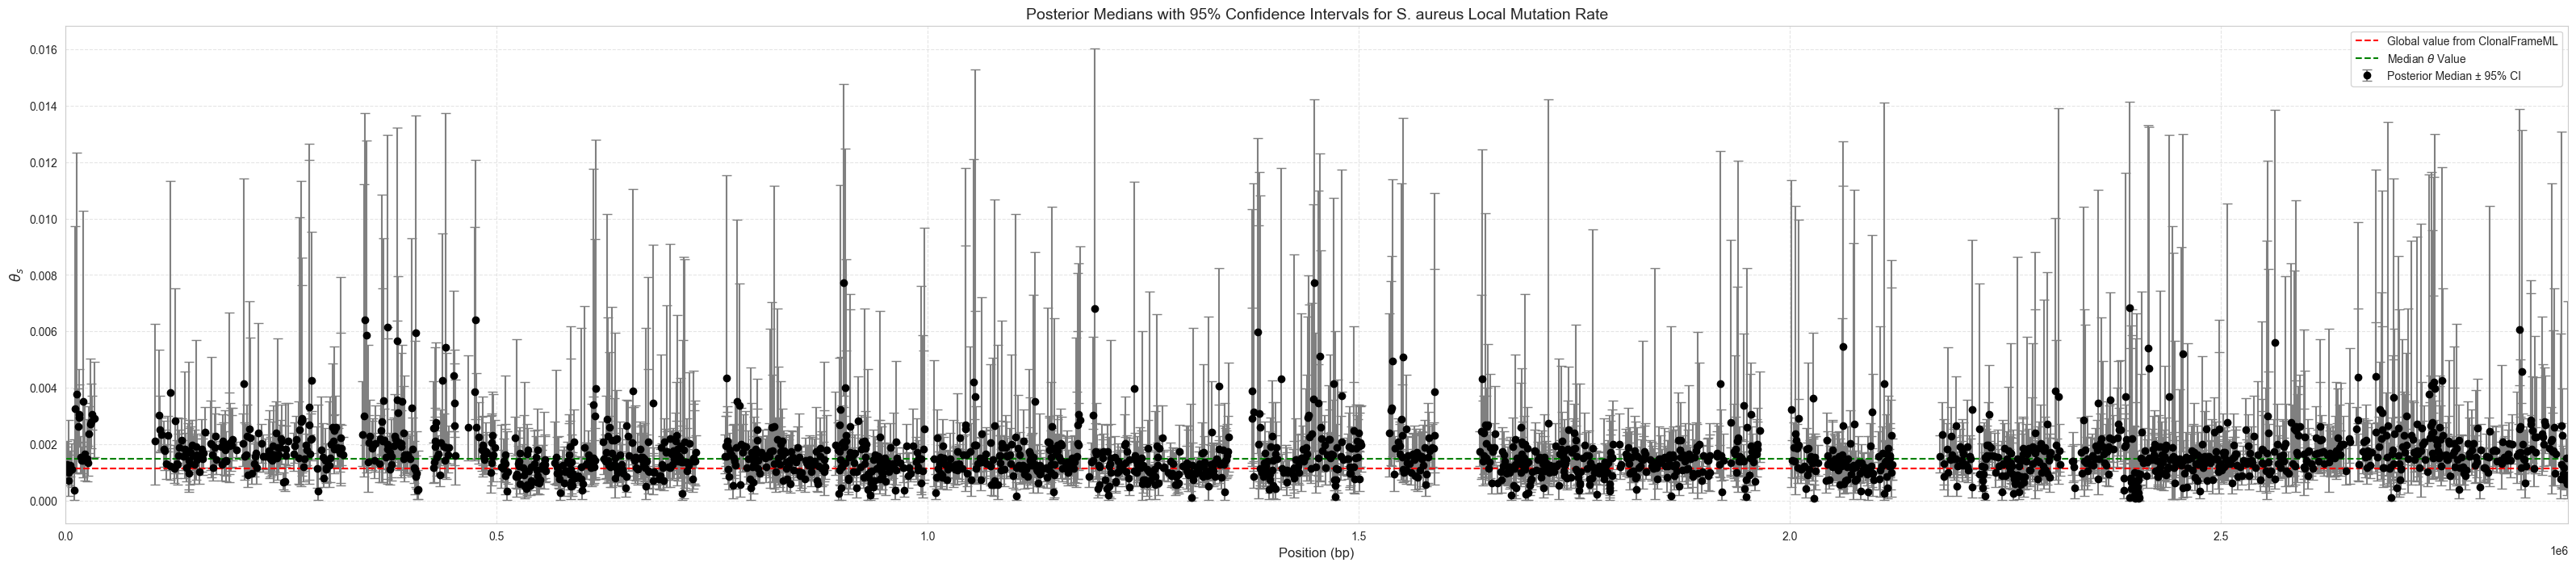

In [70]:
plt.figure(figsize=(40, 8))
plt.errorbar(samples_x, posterior_median_theta, yerr=yerr_theta, fmt='o', color='black', 
             ecolor='gray', capsize=4, elinewidth=1.5, markersize=6, 
             label='Posterior Median ± 95% CI')

plt.title("Posterior Medians with 95% Confidence Intervals for S. aureus Local Mutation Rate", fontsize=14)
plt.xlabel("Position (bp)", fontsize=12)
plt.ylabel(r'$\theta_s$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(y=0.001133205859498758, color='red', linestyle='dashed', label='Global value from ClonalFrameML')
plt.axhline(y=median_theta, color='green', linestyle='dashed', label=r'Median $\theta$ Value')
plt.xlim(plot_xlim)
plt.legend()
plt.show()

In [71]:
samples_l = np.delete(gene_info_np[:, 0], no_signal_id)
samples_l.shape

(1965,)

In [72]:
posterior_l_median = np.median(theta_post[:, :, 2], axis=1)
posterior_l_median.shape

(1965,)

In [73]:
ci_lower_bounds_l = np.percentile(theta_post[:, :, 2], 2.5, axis=1)
ci_upper_bounds_l = np.percentile(theta_post[:, :, 2], 97.5, axis=1)
ci_lower_bounds_l.shape, ci_upper_bounds_l.shape

((1965,), (1965,))

In [74]:
lower_l_errors = posterior_l_median - ci_lower_bounds_l
upper_l_errors = ci_upper_bounds_l - posterior_l_median
yerr_l = [lower_l_errors, upper_l_errors]

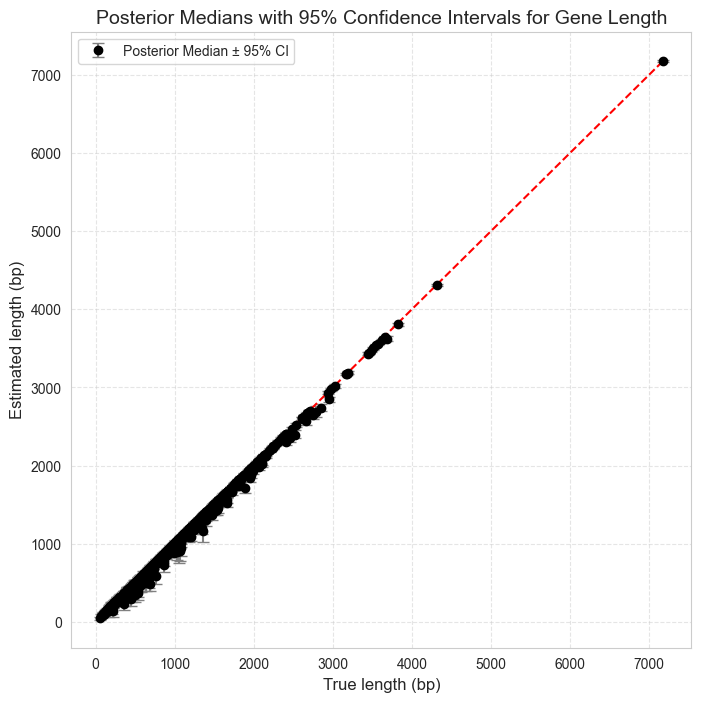

In [75]:
plt.figure(figsize=(8, 8))
plt.errorbar(samples_l, posterior_l_median, yerr=yerr_l, fmt='o', color='black', 
             ecolor='gray', capsize=4, elinewidth=1.5, markersize=6, 
             label='Posterior Median ± 95% CI')

exact_x = np.linspace(np.min(samples_l), np.max(samples_l), 400)
exact_y = exact_x

plt.title("Posterior Medians with 95% Confidence Intervals for Gene Length", fontsize=14)
plt.xlabel("True length (bp)", fontsize=12)
plt.ylabel("Estimated length (bp)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.plot(exact_x, exact_y, color='red', linestyle='dashed')
plt.legend(loc='upper left')
plt.show()

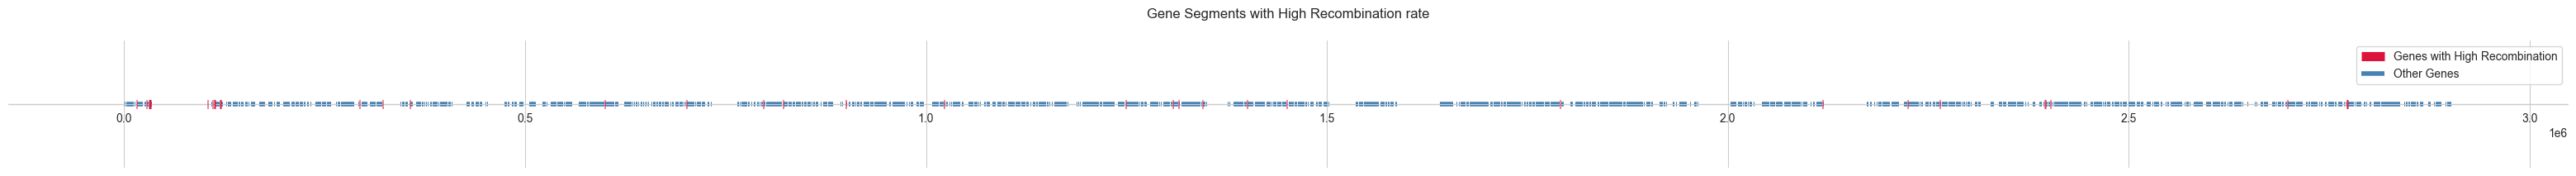

In [76]:
y_level = 0
gene_starts = np.delete(gene_info_np[:, 1], no_signal_id)
gene_ends   = np.delete(gene_info_np[:, 2], no_signal_id)

# high_recomb_index = np.where(ci_lower_bounds >= 0.0003887292720131564)[0]
high_recomb_index = np.where(ci_lower_bounds >= median_rho)[0]
highlight_starts = gene_starts[high_recomb_index]
highlight_ends   = gene_ends[high_recomb_index]

# other_genes_index = np.where(ci_lower_bounds < 0.0003887292720131564)[0]
other_genes_index = np.where(ci_lower_bounds < median_rho)[0]
other_starts = gene_starts[other_genes_index]
other_ends   = gene_ends[other_genes_index]

fig, ax = plt.subplots(figsize=(40, 2))

ax.axhline(y=y_level, color='lightgray', linewidth=1, zorder=1)
ax.hlines(y=[y_level] * len(highlight_starts), xmin=highlight_starts, xmax=highlight_ends, 
          color='crimson', linewidth=8, label='Genes with High Recombination', zorder=3)
ax.hlines(y=[y_level] * len(other_starts), xmin=other_starts, xmax=other_ends, 
          color='steelblue', linewidth=4, label='Other Genes', zorder=2)

ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_position('center')

ax.set_ylim(-1, 1)
ax.set_title("Gene Segments with High Recombination rate", pad=20)
ax.legend(loc='upper right')
plt.show()

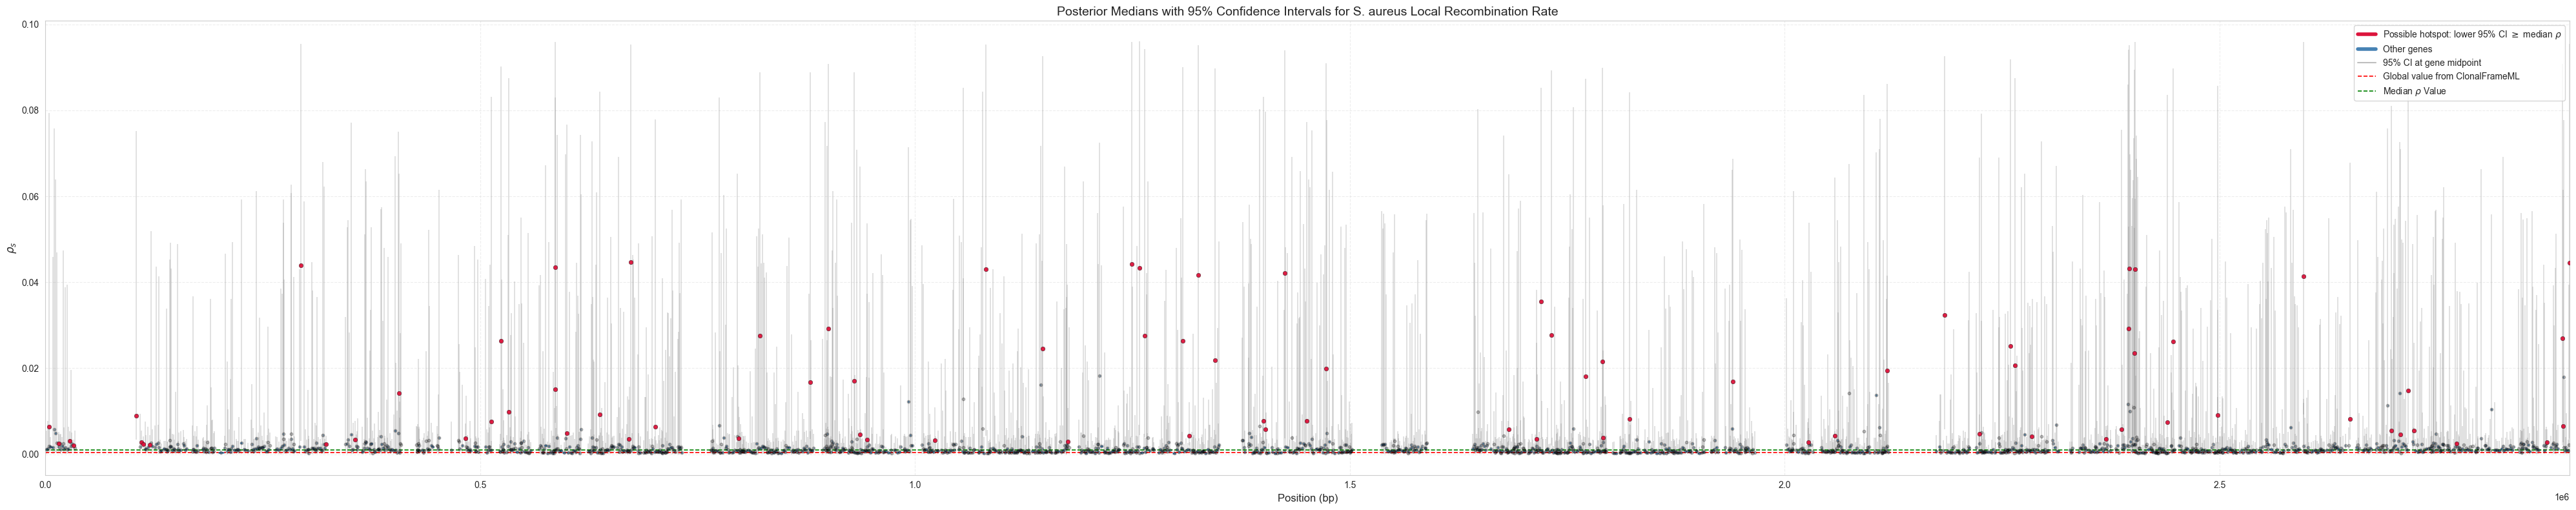

In [77]:
gene_midpoints = (gene_starts + gene_ends) / 2

y = np.asarray(posterior_median)
is_hotspot = ci_lower_bounds >= median_rho
segments = [
    [(start, rate), (end, rate)]
    for start, end, rate in zip(gene_starts, gene_ends, y)
]

colors = np.where(is_hotspot, 'crimson', 'steelblue')
linewidths = np.where(is_hotspot, 3.2, 1.8)
alphas = np.where(is_hotspot, 0.95, 0.55)

fig, ax = plt.subplots(figsize=(40, 8))

# Plot gene intervals efficiently.
lc = LineCollection(
    segments,
    colors=colors,
    linewidths=linewidths,
    alpha=1.0,
    zorder=3,
)
ax.add_collection(lc)

# Add vertical CI bars at each gene midpoint.
# These retain the CI information from your original point/errorbar plot.
ax.vlines(
    gene_midpoints,
    ci_lower_bounds,
    ci_upper_bounds,
    colors='gray',
    linewidth=1.1,
    alpha=0.30,
    zorder=1,
)

# Add small midpoint markers to make exact median locations easier to see.
ax.scatter(
    gene_midpoints[~is_hotspot],
    y[~is_hotspot],
    s=10,
    color='black',
    alpha=0.25,
    zorder=4,
)
ax.scatter(
    gene_midpoints[is_hotspot],
    y[is_hotspot],
    s=22,
    color='crimson',
    edgecolor='black',
    linewidth=0.3,
    alpha=0.95,
    zorder=5,
)

# Reference lines from your original plot.
ax.axhline(
    y=0.0003887292720131564,
    color='red',
    linestyle='dashed',
    linewidth=1.2,
    label='Global value from ClonalFrameML',
    zorder=2,
)
ax.axhline(
    y=median_rho,
    color='green',
    linestyle='dashed',
    linewidth=1.2,
    label=r'Median $\rho$ Value',
    zorder=2,
)

# Labels and styling.
ax.set_title(
    'Posterior Medians with 95% Confidence Intervals for S. aureus Local Recombination Rate',
    fontsize=14,
)
ax.set_xlabel('Position (bp)', fontsize=12)
ax.set_ylabel(r'$\rho_s$', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.35)
ax.set_xlim(plot_xlim)

# Set y limits with padding so CI bars are not clipped.
y_min = min(0, np.nanmin(ci_lower_bounds))
y_max = np.nanmax(ci_upper_bounds)
y_pad = 0.05 * (y_max - y_min)
ax.set_ylim(y_min - y_pad, y_max + y_pad)

# Custom legend for interval colors plus reference lines.
hotspot_handle = Line2D(
    [0], [0],
    color='crimson',
    lw=4,
    label=r'Possible hotspot: lower 95% CI $\geq$ median $\rho$',
)
other_handle = Line2D(
    [0], [0],
    color='steelblue',
    lw=4,
    label='Other genes',
)
ci_handle = Line2D(
    [0], [0],
    color='gray',
    lw=1.5,
    alpha=0.5,
    label='95% CI at gene midpoint',
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=[hotspot_handle, other_handle, ci_handle] + handles,
    loc='upper right',
    frameon=True,
)

plt.tight_layout()
plt.show()

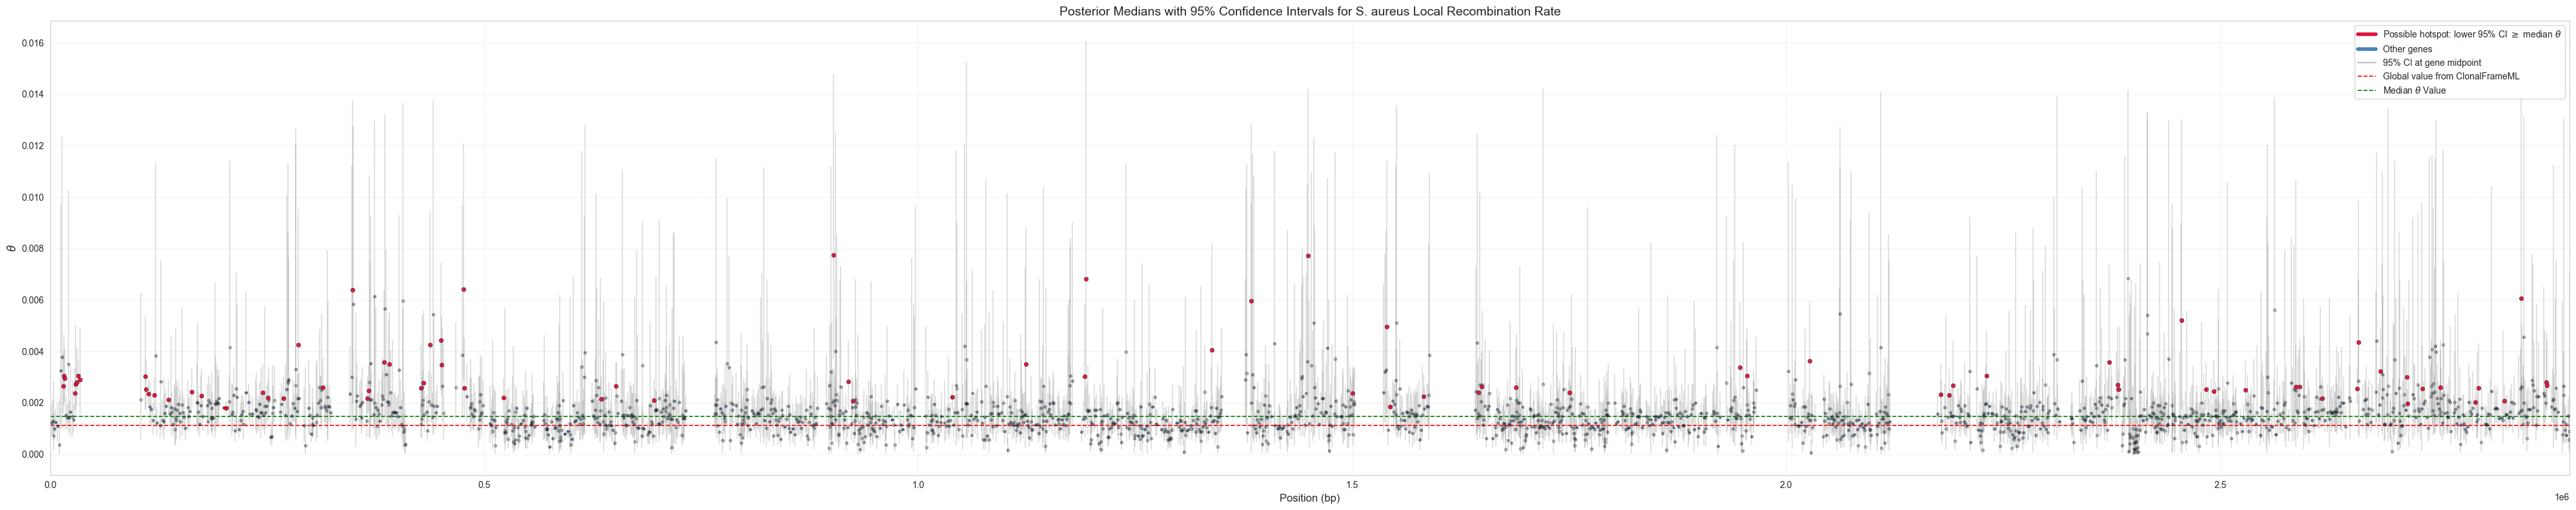

In [78]:
gene_midpoints = (gene_starts + gene_ends) / 2

y = np.asarray(posterior_median_theta)
is_hotspot = ci_lower_bounds_theta >= median_theta
segments = [
    [(start, rate), (end, rate)]
    for start, end, rate in zip(gene_starts, gene_ends, y)
]

colors = np.where(is_hotspot, 'crimson', 'steelblue')
linewidths = np.where(is_hotspot, 3.2, 1.8)
alphas = np.where(is_hotspot, 0.95, 0.55)

fig, ax = plt.subplots(figsize=(40, 8))

# Plot gene intervals efficiently.
lc = LineCollection(
    segments,
    colors=colors,
    linewidths=linewidths,
    alpha=1.0,
    zorder=3,
)
ax.add_collection(lc)

# Add vertical CI bars at each gene midpoint.
# These retain the CI information from your original point/errorbar plot.
ax.vlines(
    gene_midpoints,
    ci_lower_bounds_theta,
    ci_upper_bounds_theta,
    colors='gray',
    linewidth=1.1,
    alpha=0.30,
    zorder=1,
)

# Add small midpoint markers to make exact median locations easier to see.
ax.scatter(
    gene_midpoints[~is_hotspot],
    y[~is_hotspot],
    s=10,
    color='black',
    alpha=0.25,
    zorder=4,
)
ax.scatter(
    gene_midpoints[is_hotspot],
    y[is_hotspot],
    s=22,
    color='crimson',
    edgecolor='black',
    linewidth=0.3,
    alpha=0.95,
    zorder=5,
)

# Reference lines from your original plot.
ax.axhline(
    y=0.001133205859498758,
    color='red',
    linestyle='dashed',
    linewidth=1.2,
    label='Global value from ClonalFrameML',
    zorder=2,
)
ax.axhline(
    y=median_theta,
    color='green',
    linestyle='dashed',
    linewidth=1.2,
    label=r'Median $\theta$ Value',
    zorder=2,
)

# Labels and styling.
ax.set_title(
    'Posterior Medians with 95% Confidence Intervals for S. aureus Local Recombination Rate',
    fontsize=14,
)
ax.set_xlabel('Position (bp)', fontsize=12)
ax.set_ylabel(r'$\theta$', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.35)
ax.set_xlim(plot_xlim)

# Set y limits with padding so CI bars are not clipped.
y_min = min(0, np.nanmin(ci_lower_bounds_theta))
y_max = np.nanmax(ci_upper_bounds_theta)
y_pad = 0.05 * (y_max - y_min)
ax.set_ylim(y_min - y_pad, y_max + y_pad)

# Custom legend for interval colors plus reference lines.
hotspot_handle = Line2D(
    [0], [0],
    color='crimson',
    lw=4,
    label=r'Possible hotspot: lower 95% CI $\geq$ median $\theta$',
)
other_handle = Line2D(
    [0], [0],
    color='steelblue',
    lw=4,
    label='Other genes',
)
ci_handle = Line2D(
    [0], [0],
    color='gray',
    lw=1.5,
    alpha=0.5,
    label='95% CI at gene midpoint',
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=[hotspot_handle, other_handle, ci_handle] + handles,
    loc='upper right',
    frameon=True,
)

plt.tight_layout()
plt.show()

### Correlation plots

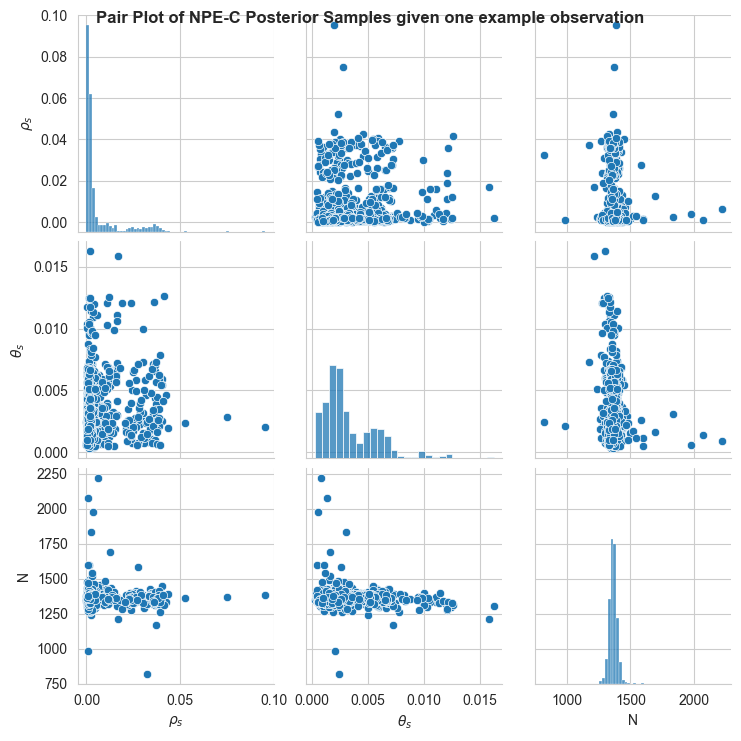

In [79]:
df_example = pd.DataFrame(theta_post[123, :, :], columns=[r"$\rho_s$", r"$\theta_s$", "N"])
sns.pairplot(df_example)
plt.suptitle('Pair Plot of NPE-C Posterior Samples given one example observation', fontsize=12, fontweight='bold')
plt.show()

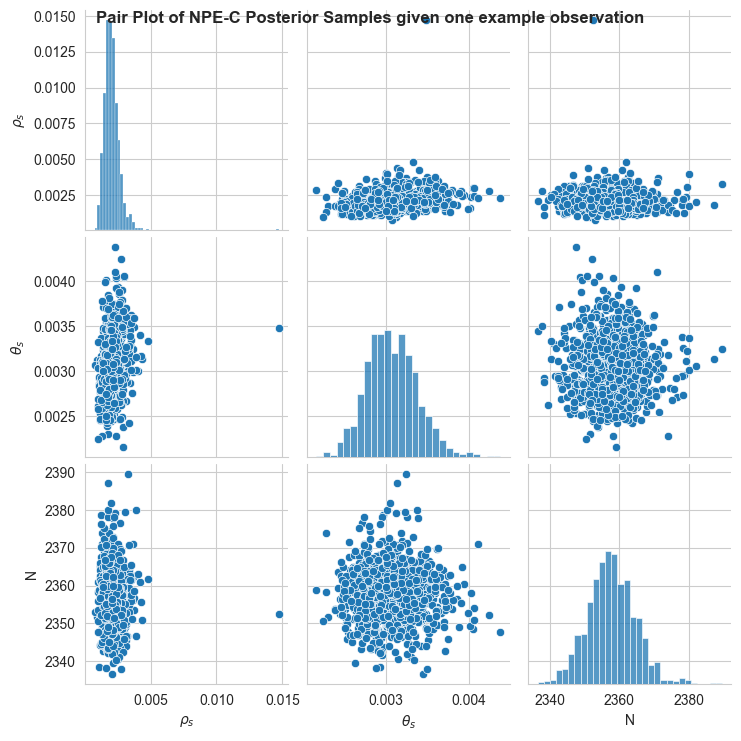

In [80]:
df_example = pd.DataFrame(theta_post[22, :, :], columns=[r"$\rho_s$", r"$\theta_s$", "N"])
sns.pairplot(df_example)
plt.suptitle('Pair Plot of NPE-C Posterior Samples given one example observation', fontsize=12, fontweight='bold')
plt.show()